In [ ]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
hdu = fits.open('./calibration/alias/pyr3.0_s1.4_600modes_alias.fits')
psd_data = hdu[0].data
freq = hdu[1].data
pow14 = hdu[2].data

print(psd_data.shape,freq.shape)

(600, 513) (513,)


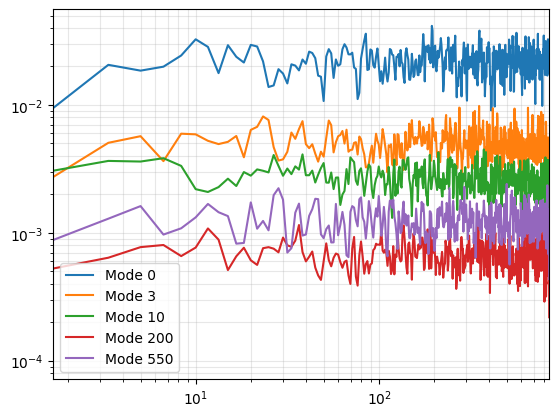

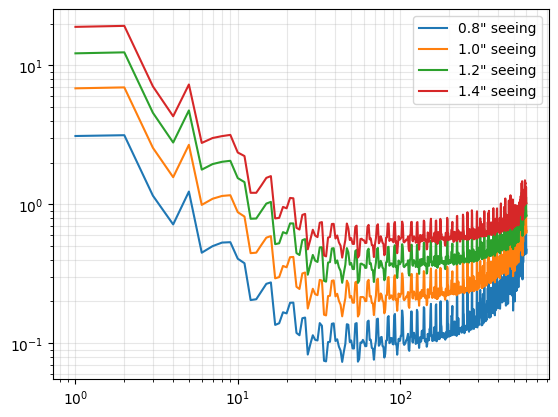

In [ ]:
plt.figure()
for mode in np.array([0,3,10,200,550]):
    plt.loglog(freq,psd_data[mode],label=f'Mode {mode}')
plt.legend()
plt.grid(which='both',alpha=0.3)
plt.xlim([freq[1],freq[-1]])

hdu = fits.open('./calibration/alias/pyr3.0_s1.2_600modes_alias.fits')
pow12 = hdu[2].data
hdu = fits.open('./calibration/alias/pyr3.0_s1.0_600modes_alias.fits')
pow10 = hdu[2].data
hdu = fits.open('./calibration/alias/pyr3.0_s0.8_600modes_alias.fits')
pow08 = hdu[2].data
hdu = fits.open('./calibration/alias/pyr3.0_s0.6_500modes_alias.fits')
pow06 = hdu[2].data

plt.figure()
plt.loglog(np.arange(len(pow06))+1,pow06,label='0.8" seeing')
plt.loglog(np.arange(len(pow08))+1,pow08,label='0.8" seeing')
plt.loglog(np.arange(len(pow10))+1,pow10,label='1.0" seeing')
plt.loglog(np.arange(len(pow12))+1,pow12,label='1.2" seeing')
plt.loglog(np.arange(len(pow14))+1,pow14,label='1.4" seeing')
plt.grid(which='both',alpha=0.3)
plt.legend()

In [ ]:
Nmodes = 400
def compute_rec(im,Nmodes):
    U,S,Vt = np.linalg.svd(im[:,:Nmodes],full_matrices=False)
    return (Vt.T * 1/S) @ U.T

im = fits.getdata('./calibration/im/pyr3.0_im.fits')
im_ri = fits.getdata('./calibration/im/pyr3.0_im_ri.fits')

rec = compute_rec(im,Nmodes)
rec_ri = compute_rec(im_ri, Nmodes)

In [ ]:

npix = 120
np_size = (npix,npix)

pup_hdu = fits.open('./calibration/pupils/pyr_pupdata.fits')
rad = pup_hdu[2].data
cx = pup_hdu[3].data
cy = pup_hdu[4].data
pup_ids = pup_hdu[1].data

pyr_masks = np.zeros(np_size)
for j in range(len(rad)):
    f = np.zeros(npix**2)
    np.put(f, pup_ids[:,j], 1)
    f2d = f.reshape(np_size)
    pyr_masks += f2d

159310.03 159310.03847961425


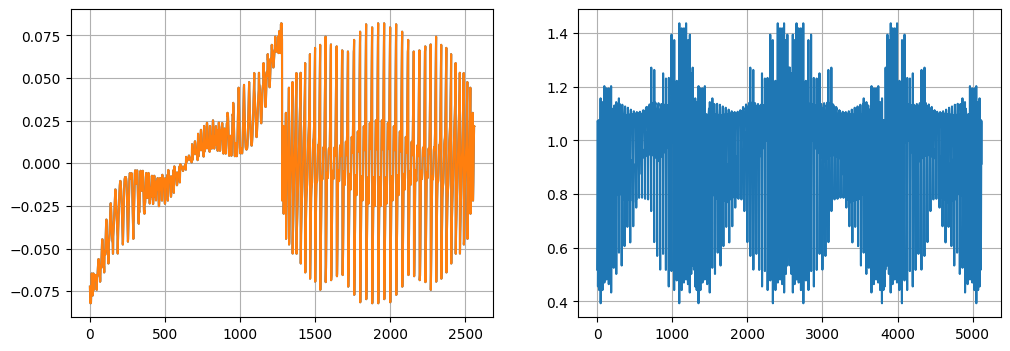

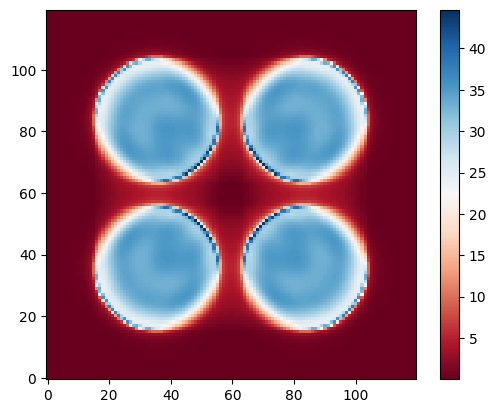

In [ ]:
frame = fits.getdata('./calibration/slopenulls/pyr3.0_frame_null.fits')[0]

sn = fits.getdata('./calibration/slopenulls/pyr3.0_slope_null.fits')
sn_ri = fits.getdata('./calibration/slopenulls/pyr3.0_slope_null_ri.fits')

thrp = np.sum(frame[pyr_masks.astype(bool)])/np.sum(frame)

# sn /= np.sum(abs(sn))
# sn_ri /= np.sum(abs(sn_ri))/thrp
n_subaps = np.sum(pyr_masks)/4

weights = np.array([[1,1,-1,-1],[-1,1,1,-1]])
sn_bis = (weights @ sn_ri.reshape([4,int(n_subaps)])/4).flatten()

print(np.sum(frame[pyr_masks.astype(bool)]),np.sum(sn_ri*np.sum(frame)*thrp/n_subaps/4))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(sn)
plt.plot(sn_bis)
plt.grid()
plt.subplot(1,2,2)
plt.plot(sn_ri)
plt.grid()

plt.figure()
plt.imshow(frame,cmap='RdBu',origin='lower')
plt.colorbar()

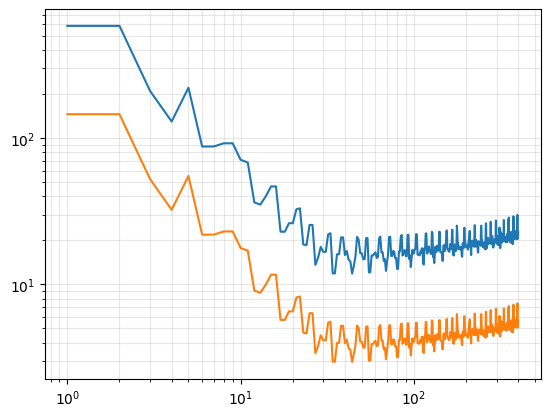

In [ ]:
rec_cov = np.diag(rec @ rec.T)
rec_cov_ri = np.diag(rec_ri @ rec_ri.T)

x = np.arange(rec_cov.shape[0])+1

plt.figure()
plt.loglog(x,rec_cov)
plt.loglog(x,rec_cov_ri)
plt.grid(which='both',alpha=0.3)

In [ ]:
def n_photons(mag, diameter, fs, thrp = 1.0, obsratio=0.0):
    B0 = 1e+10 # ph/m^2/s
    area = np.pi/4*(diameter**2-(obsratio*diameter)**2)
    flux = B0*10**(-mag/2.5) # ph/m^2/s
    n_phot = flux * area / fs * thrp
    return n_phot

def compute_slope_noise_variance(sn_ri, D:float, mag:float, fs:float,
                                F_excess:float=1.0, RON:float=0.5, slopes_from_intensity:bool=False,
                                sky_bkg:float=0.0, dark_curr:float=0.0):

    n_subaps = int(len(sn_ri)/4)
    n_phot = n_photons(mag, D, fs)
    phot_per_pix = sn_ri*n_phot/n_subaps/4
    pixel_variance = F_excess ** 2 * (phot_per_pix + sky_bkg + dark_curr) + RON

    if slopes_from_intensity is False:
        weights = np.array([[1,1,-1,-1],[-1,1,1,-1]])
        pixel_variance = pixel_variance.reshape([4,n_subaps])
        slope_variance = weights**2 @ pixel_variance / (4*n_phot) ** 2   
    else:
        slope_variance = pixel_variance / n_phot ** 2 
                                         
    return slope_variance.flatten()

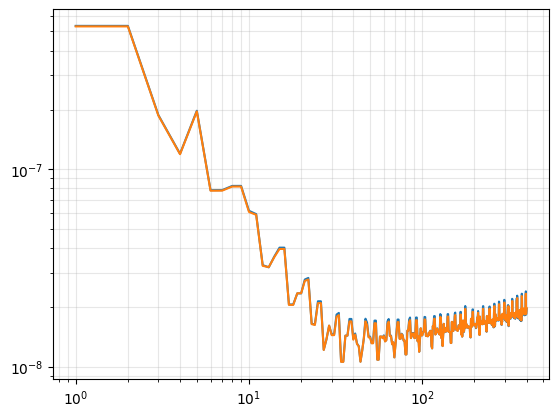

In [ ]:
D = 8.4
mag = 9.5
fs = 1000
n_subaps = int(np.sum(pyr_masks)/4)

slopes_cov = compute_slope_noise_variance(sn_ri=sn_ri, D=D, mag=mag, fs=fs, slopes_from_intensity=False, RON=10)
metaint_cov = compute_slope_noise_variance(sn_ri=sn_ri, D=D, mag=mag, fs=fs, slopes_from_intensity=True, RON=10)


# plt.figure()
# plt.loglog(slopes_cov)
# plt.loglog(metaint_cov)
# plt.grid(which='both',alpha=0.3)

plt.figure()
plt.loglog(x,np.diag(rec @ np.diag(slopes_cov) @ rec.T))
plt.loglog(x,np.diag(rec_ri @ np.diag(metaint_cov) @ rec_ri.T))
plt.grid(which='both',alpha=0.3)

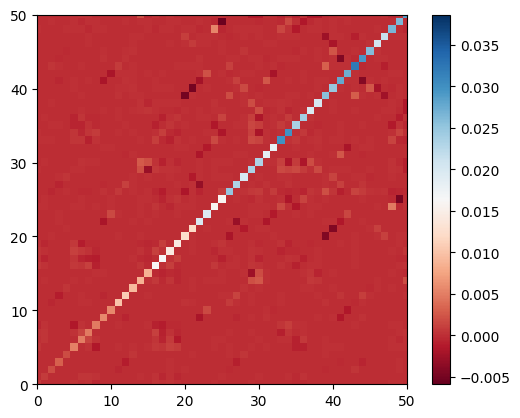

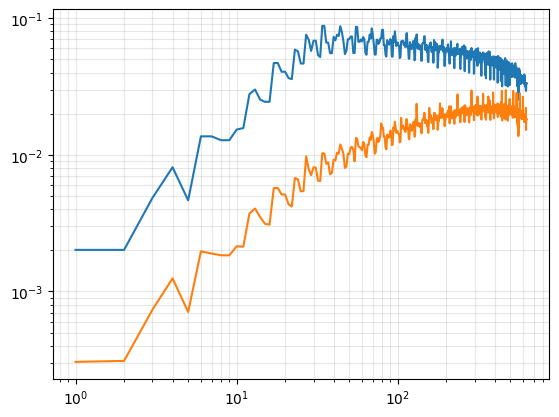

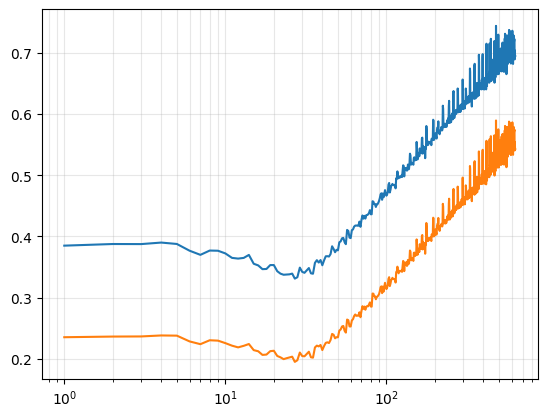

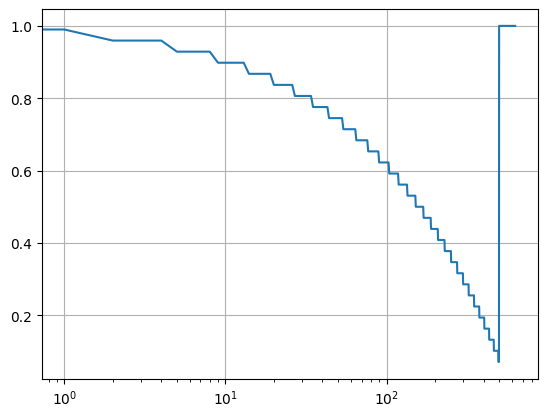

In [ ]:
def compute_optical_gain(IM, IMpc):
    norm = np.diag(IM.T @ IM)
    return np.diag(IMpc.T @ IM)/norm

im_pc = fits.getdata('./calibration/im/pyr3.0_s1.0_c0.9_im.fits')
im_pc2 = fits.getdata('./calibration/im/pyr3.0_s1.4_c0.9_im.fits')
cvec = fits.getdata('./calibration/data/correction_vector_500modes_c0.99.fits')

ogs = compute_optical_gain(im, im_pc)
ogs2 = compute_optical_gain(im, im_pc2)
norm = np.diag(im.T @ im)
norm_pc = np.diag(im_pc.T @ im_pc)

plt.figure()
plt.imshow(im_pc.T @ im,cmap='RdBu')
plt.colorbar()
plt.xlim([0,50])
plt.ylim([0,50])

plt.figure()
plt.plot(np.arange(len(ogs))+1,norm)
plt.plot(np.arange(len(ogs))+1,norm_pc)
plt.xscale('log')
plt.yscale('log')
plt.grid(which='both',alpha=0.3)


plt.figure()
plt.plot(np.arange(len(ogs))+1,ogs)
plt.plot(np.arange(len(ogs))+1,ogs2)
plt.xscale('log')
plt.grid(which='both',alpha=0.3)

plt.figure()
plt.plot(cvec)
plt.xscale('log')
plt.grid()